<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v2_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'AU-PEMal-2025-V2_Cleaned.csv' not found. Resolving and cleaning raw dataset...
Please upload 'AU-PEMal-2025-V2.csv':


Saving AU-PEMal-2025-V2.csv to AU-PEMal-2025-V2.csv
Initial Dataset Shape: 21703 rows, 39 columns
Dropped non-predictive hash/identifier columns: ['sha1']
Saved Cleaned Dataset 'AU-PEMal-2025-V2_Cleaned.csv' (21572 rows, 36 columns).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Loading Cleaned Dataset: 'AU-PEMal-2025-V2_Cleaned.csv' ---
Feature Matrix Shape: (21572, 35)
Class Distribution: {'Malware': np.int64(10803), 'Benign': np.int64(10769)}

--- Training Random Forest Classifier ---

================ EVALUATION METRICS ================
Overall Accuracy: 99.35%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     0.9963    0.9907    0.9935      2154
     Malware     0.9908    0.9963    0.9935      2161

    accuracy                         0.9935      4315
   macro avg     0.9935    0.9935    0.9935      4315
weighted avg     0.9935    0.9935    0.9935      4315

================ CONFUSION RATE ANALYSIS ================
Total Test Samples Evaluated: 4315
True Benign Count: 2154 | True Malware Count: 2161

False Positives (Benign misclassified as Malware): 20 (0.93% confusion rate)
False Negatives (Malware misclassified as Benign): 8 (0.37% confusion rate)
Overall Dataset Misclassification/Confusion Rate: 0.65

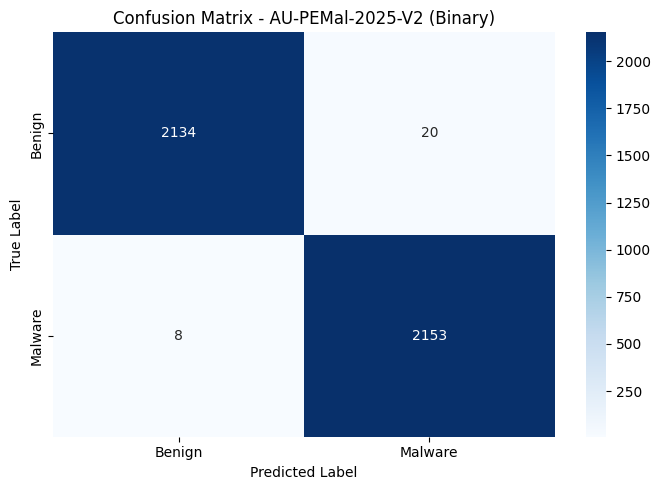

================ TOP 10 FEATURE IMPORTANCES ================
 1. processes_malicious            Score: 0.430145
 2. files_malicious                Score: 0.109776
 3. registry_total                 Score: 0.076813
 4. processes_monitored            Score: 0.054199
 5. files_suspicious               Score: 0.043968
 6. network_dns                    Score: 0.039895
 7. registry_read                  Score: 0.032596
 8. files_text                     Score: 0.031864
 9. files_unknown                  Score: 0.029492
10. total_procsses                 Score: 0.024119


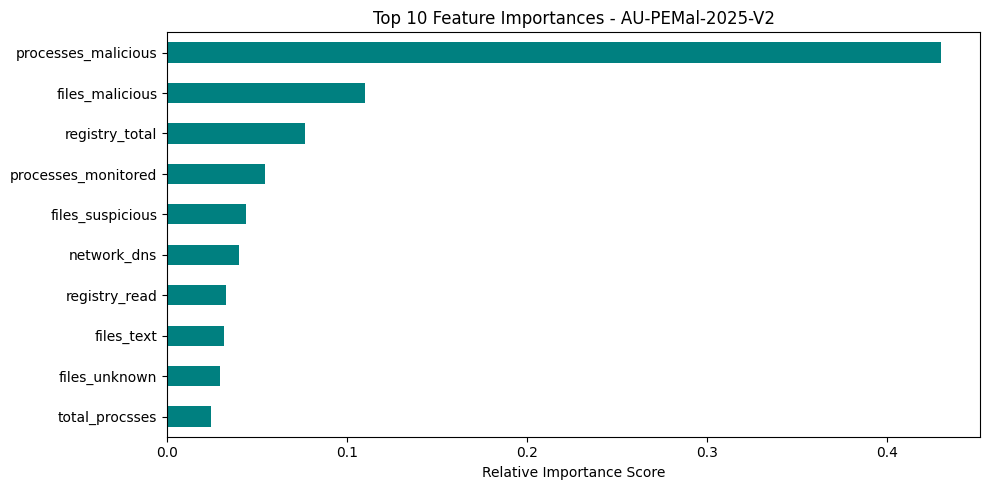

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

input_file = "AU-PEMal-2025-V2.csv"
output_file = "AU-PEMal-2025-V2_Cleaned.csv"

# =========================================================
# STEP 1: DATASET CLEANING & EXPORT
# =========================================================
if not os.path.exists(output_file):
    print(
        f"'{output_file}' not found. Resolving and cleaning raw dataset..."
    )

    # Locate raw dataset if needed
    if not os.path.exists(input_file):
        raw_files = [
            f for f in glob.glob("AU-PEMal-2025-V2*.csv") if "Cleaned" not in f
        ]
        if raw_files:
            input_file = raw_files[0]
            print(f"Found raw dataset: '{input_file}'")
        else:
            try:
                from google.colab import files

                print(f"Please upload '{input_file}':")
                uploaded = files.upload()
                input_file = list(uploaded.keys())[0]
            except ImportError:
                raise FileNotFoundError(
                    f"Cannot locate '{input_file}' in the working directory."
                )

    # Read raw dataset
    df_raw = pd.read_csv(input_file)
    print(
        f"Initial Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns"
    )

    # Drop non-predictive hash/identifier columns
    non_feature_cols = [
        "sha1",
        "Name",
        "filename",
        "Raw_filename",
        "hash",
        "md5",
    ]
    cols_to_drop = [c for c in non_feature_cols if c in df_raw.columns]
    if cols_to_drop:
        df_raw = df_raw.drop(columns=cols_to_drop)
        print(
            f"Dropped non-predictive hash/identifier columns: {cols_to_drop}"
        )

    # Parse PE Header Hexadecimal columns ('0x...') to numeric integers
    hex_cols = [
        "EntryPoint",
        "SizeOfCode",
        "SizeOfImage",
        "SizeOfInitializedData",
        "SizeOfUninitializedData",
        "rdata_VirtualSize",
        "rdata_VirtualAddress",
        "rdata_SizeOfRawData",
        "rdata_PointerToRawData",
        "text_VirtualSize",
        "text_SizeOfRawData",
        "text_PointerToRawData",
        "BaseOfCode",
        "BaseOfData",
        "ImageBase",
        "Checksum",
        "SectionAlignment",
        "SizeOfHeaders",
    ]

    def parse_hex_to_int(val):
        if pd.isna(val):
            return 0
        val_str = str(val).strip()
        try:
            if val_str.lower().startswith("0x"):
                return int(val_str, 16)
            else:
                return int(float(val_str))
        except Exception:
            return 0

    for col in hex_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].apply(parse_hex_to_int)

    # Target Normalization (Binary: Benign vs. Malware)
    if "Class" in df_raw.columns:
        binary_series = df_raw["Class"].copy()
    elif "Category" in df_raw.columns:
        binary_series = df_raw["Category"].apply(
            lambda x: (
                "Benign" if str(x).strip().lower() == "benign" else "Malware"
            )
        )
    elif "Family" in df_raw.columns:
        binary_series = df_raw["Family"].apply(
            lambda x: (
                "Benign" if str(x).strip().lower() == "benign" else "Malware"
            )
        )
    else:
        raise ValueError(
            "No class or label column found for binary classification."
        )

    def standardize_label(val):
        val_str = str(val).strip().lower()
        if val_str in ["0", "benign", "goodware"]:
            return "Benign"
        return "Malware"

    y_binary = binary_series.apply(standardize_label)

    # Strip out categorical target and metadata columns from features
    all_target_labels = ["Class", "Category", "Family", "label", "target"]
    X_clean = df_raw.drop(
        columns=[c for c in all_target_labels if c in df_raw.columns]
    )
    X_clean = X_clean.select_dtypes(include=[np.number])

    # Drop zero-variance constant features
    constant_cols = [c for c in X_clean.columns if X_clean[c].nunique() <= 1]
    if constant_cols:
        X_clean = X_clean.drop(columns=constant_cols)
        print(f"Dropped zero-variance constant columns: {constant_cols}")

    # Deduplicate and remove missing values
    df_cleaned = pd.concat([X_clean, y_binary.rename("Class")], axis=1)
    df_cleaned = df_cleaned.dropna().drop_duplicates(keep="first")

    # Save cleaned dataset
    df_cleaned.to_csv(output_file, index=False)
    print(
        f"Saved Cleaned Dataset '{output_file}' ({df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns)."
    )

    try:
        from google.colab import files

        files.download(output_file)
    except Exception:
        pass

# =========================================================
# STEP 2: LOAD CLEANED DATASET & PREPROCESS
# =========================================================
print(f"\n--- Loading Cleaned Dataset: '{output_file}' ---")
df = pd.read_csv(output_file)

X = df.drop(columns=["Class"]).select_dtypes(include=[np.number])
y_raw = df["Class"]

# Label Encoding (Benign -> 0, Malware -> 1)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = [str(c) for c in label_encoder.classes_]

print(f"Feature Matrix Shape: {X.shape}")
print(f"Class Distribution: {dict(pd.Series(y_raw).value_counts())}")

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# STEP 3: MODEL TRAINING (RANDOM FOREST)
# =========================================================
print("\n--- Training Random Forest Classifier ---")
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# =========================================================
# STEP 4: EVALUATION METRICS & CONFUSION RATE ANALYSIS
# =========================================================
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("\n================ EVALUATION METRICS ================")
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("CLASSIFICATION REPORT:")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# Confusion Matrix Analysis
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

benign_total = tn + fp
malware_total = fn + tp
total_samples = len(y_test)

# Confusion / Misclassification Rates
fpr = (fp / benign_total) * 100 if benign_total > 0 else 0.0  # Benign -> Malware
fnr = (
    (fn / malware_total) * 100 if malware_total > 0 else 0.0
)  # Malware -> Benign
overall_confusion_rate = ((fp + fn) / total_samples) * 100

print("================ CONFUSION RATE ANALYSIS ================")
print(f"Total Test Samples Evaluated: {total_samples}")
print(
    f"True Benign Count: {benign_total} | True Malware Count: {malware_total}\n"
)
print(
    f"False Positives (Benign misclassified as Malware): {fp} ({fpr:.2f}% confusion rate)"
)
print(
    f"False Negatives (Malware misclassified as Benign): {fn} ({fnr:.2f}% confusion rate)"
)
print(
    f"Overall Dataset Misclassification/Confusion Rate: {overall_confusion_rate:.2f}%\n"
)

# =========================================================
# STEP 5: VISUALIZATIONS (CONFUSION MATRIX & FEATURE IMPORTANCE)
# =========================================================
# 1. Plot Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - AU-PEMal-2025-V2 (Binary)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("v2_binary_confusion_matrix.png", dpi=300)
plt.show()

# 2. Extract and Plot Top 10 Feature Importances
importances = pd.Series(clf.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

print("================ TOP 10 FEATURE IMPORTANCES ================")
for rank, (feature, score) in enumerate(top_10.items(), 1):
    print(f"{rank:2d}. {feature:<30} Score: {score:.6f}")

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances - AU-PEMal-2025-V2")
plt.xlabel("Relative Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("v2_top10_feature_importances.png", dpi=300)
plt.show()